# 🛡️ Android Malware Detection - Industry-Level ML Pipeline

## Project Overview

This notebook implements a production-ready machine learning pipeline for detecting Android malware using static analysis features.

**Dataset:** CICANDMAL2020 Static Dataset
- **Samples:** 357,805 Android applications
- **Features:** 9,505 static analysis features
- **Classes:** 15 malware types (Binary: Benign vs Malware, Multi-class: 15 types)

**Objective:** Build a robust, scalable ML model for real-world malware detection

## 📋 Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Data Loading & Exploration](#2-data-loading--exploration)
3. [Data Preprocessing](#3-data-preprocessing)
4. [Feature Engineering](#4-feature-engineering)
5. [Model Training & Evaluation](#5-model-training--evaluation)
6. [Model Comparison](#6-model-comparison)
7. [Hyperparameter Tuning](#7-hyperparameter-tuning)
8. [Feature Importance Analysis](#8-feature-importance-analysis)
9. [Model Validation & Testing](#9-model-validation--testing)
10. [Production Model Selection](#10-production-model-selection)
11. [Model Deployment Preparation](#11-model-deployment-preparation)


## 1. Environment Setup


In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
import joblib
from datetime import datetime
import time
import gc  # Garbage collector for memory management

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Try to import psutil for memory monitoring
try:
    import psutil
    PSUTIL_AVAILABLE = True
except ImportError:
    PSUTIL_AVAILABLE = False
    print("⚠️  psutil not available. Install with: pip install psutil")

# Visualization settings
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('default')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Memory management
gc.enable()

print("✅ Environment setup complete!")
print(f"📅 Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
if PSUTIL_AVAILABLE:
    memory = psutil.virtual_memory()
    print(f"💻 System Memory: {memory.total / 1024**3:.2f} GB total, {memory.available / 1024**3:.2f} GB available")


✅ Environment setup complete!
📅 Date: 2025-12-13 17:13:06
💻 System Memory: 8.00 GB total, 1.70 GB available


## 2. Data Loading & Exploration


In [2]:
# Load complete dataset with memory optimization
print("📂 Loading complete dataset...")
print("💡 Using full dataset for maximum model performance")

start_time = time.time()

try:
    # Load full dataset
    print("  Loading parquet file...")
    df = pd.read_parquet('DataSet/cicandmal2020-static.parquet')
    
    load_time = time.time() - start_time
    print(f"✅ Dataset loaded in {load_time:.2f} seconds")
    print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"💾 Memory usage: {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")
    
    # Memory check
    if PSUTIL_AVAILABLE:
        available_memory = psutil.virtual_memory().available / 1024**3
        total_memory = psutil.virtual_memory().total / 1024**3
        print(f"💻 System Memory: {total_memory:.2f} GB total, {available_memory:.2f} GB available")
        
        dataset_memory = df.memory_usage(deep=True).sum() / 1024**3
        if dataset_memory > available_memory * 0.9:
            print("⚠️  WARNING: Dataset uses >90% of available memory.")
            print("   Consider closing other applications or using a machine with more RAM.")
    
    # Optimize data types to reduce memory usage
    print("\n🔧 Optimizing data types to reduce memory...")
    memory_before = df.memory_usage(deep=True).sum() / 1024**3
    
    # Convert int64 to smaller types where possible
    for col in df.select_dtypes(include=['int64']).columns:
        if col not in ['F0', 'Label']:
            col_min = df[col].min()
            col_max = df[col].max()
            if col_min >= np.iinfo(np.int8).min and col_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype('int8')
            elif col_min >= np.iinfo(np.int16).min and col_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype('int16')
            elif col_min >= np.iinfo(np.int32).min and col_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype('int32')
    
    memory_after = df.memory_usage(deep=True).sum() / 1024**3
    memory_saved = memory_before - memory_after
    print(f"  ✅ Memory optimized: {memory_before:.2f} GB → {memory_after:.2f} GB")
    print(f"  💾 Saved: {memory_saved:.2f} GB ({memory_saved/memory_before*100:.1f}%)")
    
    # Force garbage collection
    gc.collect()
    
except MemoryError as e:
    print(f"❌ Memory error loading dataset: {e}")
    print("💡 Suggestions:")
    print("   1. Close other applications to free up RAM")
    print("   2. Use a machine with at least 8GB RAM (16GB recommended)")
    print("   3. Restart Python kernel and try again")
    raise
except Exception as e:
    print(f"❌ Error loading dataset: {e}")
    raise


📂 Loading complete dataset...
💡 Using full dataset for maximum model performance
  Loading parquet file...
✅ Dataset loaded in 2.54 seconds
📊 Shape: 357,805 rows × 9505 columns
💾 Memory usage: 3.22 GB
💻 System Memory: 8.00 GB total, 1.39 GB available
⚠️  WARNING: Dataset uses >90% of available memory.
   Consider closing other applications or using a machine with more RAM.

🔧 Optimizing data types to reduce memory...
  ✅ Memory optimized: 3.22 GB → 3.22 GB
  💾 Saved: 0.00 GB (0.0%)


In [3]:
# Basic dataset information
print("="*70)
print("DATASET OVERVIEW")
print("="*70)

print(f"\n📋 Column Information:")
print(f"  Total columns: {len(df.columns)}")
print(f"  Feature columns: {len([c for c in df.columns if c not in ['F0', 'Label']])}")
print(f"  Data types:")
print(df.dtypes.value_counts())

# Check for missing values
missing_values = df.isnull().sum()
missing_cols = missing_values[missing_values > 0]
print(f"\n❓ Missing Values:")
if len(missing_cols) > 0:
    print(f"  Columns with missing values: {len(missing_cols)}")
    print(missing_cols.head(10))
else:
    print("  ✅ No missing values found")

# Label distribution
print(f"\n🎯 Label Distribution:")
label_counts = df['Label'].value_counts()
label_percentages = (label_counts / len(df) * 100).round(2)
print(label_counts)
print(f"\n📊 Percentages:")
print(label_percentages)


DATASET OVERVIEW

📋 Column Information:
  Total columns: 9505
  Feature columns: 9503
  Data types:
int8       9495
int16         4
float32       4
object        2
Name: count, dtype: int64

❓ Missing Values:
  Columns with missing values: 4
F9500    41
F9501    41
F9502    41
F9503    42
dtype: int64

🎯 Label Distribution:
Label
Benign          162181
Riskware         97349
Adware           47210
Trojan           13559
Zeroday          13340
Ransomware        6202
Spy               3540
SMS               3125
Dropper           2302
NoCategory        2296
PUA               2051
Scareware         1556
Backdoor          1538
Banker             887
FileInfector       669
Name: count, dtype: int64

📊 Percentages:
Label
Benign          45.33
Riskware        27.21
Adware          13.19
Trojan           3.79
Zeroday          3.73
Ransomware       1.73
Spy              0.99
SMS              0.87
Dropper          0.64
NoCategory       0.64
PUA              0.57
Scareware        0.43
Backdoor   

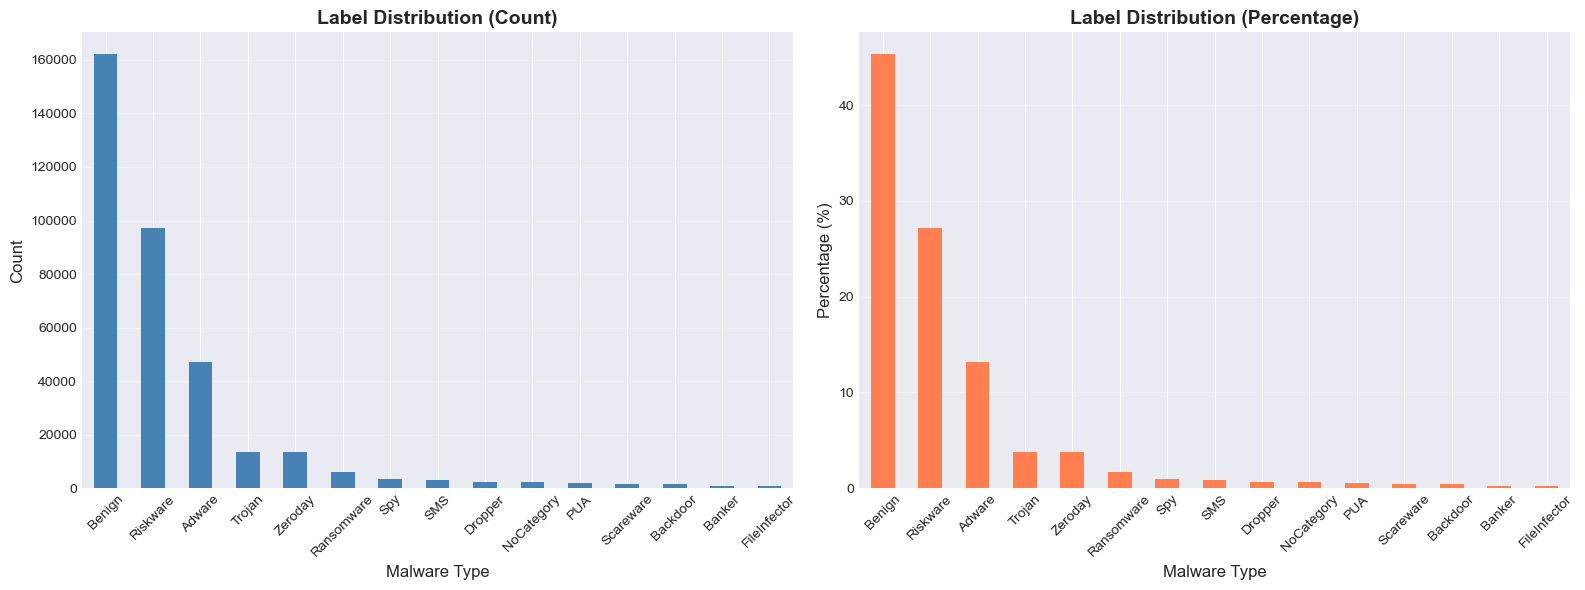


⚖️ Class Imbalance Analysis:
  Maximum class count: 162,181
  Minimum class count: 669
  Imbalance ratio: 242.42:1
  ⚠️ Significant class imbalance detected - consider balancing techniques


In [4]:
# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count plot
label_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Label Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Malware Type', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Percentage plot
label_percentages.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Label Distribution (Percentage)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Malware Type', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Class imbalance analysis
print("\n⚖️ Class Imbalance Analysis:")
max_count = label_counts.max()
min_count = label_counts.min()
imbalance_ratio = max_count / min_count
print(f"  Maximum class count: {max_count:,}")
print(f"  Minimum class count: {min_count:,}")
print(f"  Imbalance ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 10:
    print("  ⚠️ Significant class imbalance detected - consider balancing techniques")


## 3. Data Preprocessing


In [5]:
# Separate features and target
print("🔧 Preparing features and target...")

# Exclude identifier (F0) and target (Label)
feature_columns = [col for col in df.columns if col not in ['F0', 'Label']]
X = df[feature_columns].copy()
y = df['Label'].copy()

print(f"  Features: {X.shape[1]:,}")
print(f"  Samples: {X.shape[0]:,}")
print(f"  Classes: {y.nunique()}")


🔧 Preparing features and target...
  Features: 9,503
  Samples: 357,805
  Classes: 15


In [6]:
# Handle missing values
print("\n🧹 Handling missing values...")
missing_before = X.isnull().sum().sum()
print(f"  Missing values before: {missing_before:,}")

# Fill missing values with 0 (common for sparse feature matrices)
X = X.fillna(0)

missing_after = X.isnull().sum().sum()
print(f"  Missing values after: {missing_after:,}")

# Convert to numeric (handle any object types)
print("\n🔄 Converting to numeric types...")
object_cols = X.select_dtypes(include=['object']).columns
if len(object_cols) > 0:
    print(f"  Converting {len(object_cols)} object columns to numeric")
    for col in object_cols:
        X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)
else:
    print("  ✅ All columns are already numeric")



🧹 Handling missing values...
  Missing values before: 165
  Missing values after: 0

🔄 Converting to numeric types...
  ✅ All columns are already numeric


In [7]:
# Check for infinite values
print("\n🔍 Checking for infinite values...")
inf_count = np.isinf(X.select_dtypes(include=[np.number])).sum().sum()
if inf_count > 0:
    print(f"  ⚠️ Found {inf_count} infinite values - replacing with 0")
    X = X.replace([np.inf, -np.inf], 0)
else:
    print("  ✅ No infinite values found")



🔍 Checking for infinite values...
  ✅ No infinite values found


In [6]:
# Train-test split with stratification
print("\n✂️ Splitting data into train and test sets...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y  # Maintain class distribution
)

print(f"  Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify stratification
print("\n📊 Class distribution verification:")
train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist = y_test.value_counts(normalize=True).sort_index()
print("  Train distribution matches test distribution: ", np.allclose(train_dist, test_dist, atol=0.01))



✂️ Splitting data into train and test sets...
  Training set: 286,244 samples (80.0%)
  Test set: 71,561 samples (20.0%)

📊 Class distribution verification:
  Train distribution matches test distribution:  True


## 4. Feature Engineering


In [7]:
# Feature scaling (optional - Random Forest doesn't require it)
# Only scale for Logistic Regression which needs it
print("📏 Feature Scaling Configuration...")
print("  💡 Random Forest doesn't require scaling")
print("  💡 Scaling will be done on-the-fly only for Logistic Regression")

# Don't create scaler yet - will create when needed
# This saves memory
scaler = None
X_train_scaled = None
X_test_scaled = None

print("  ✅ Scaling configured (on-the-fly for Logistic Regression only)")
print("  💾 Memory saved by not pre-scaling entire dataset")


📏 Feature Scaling Configuration...
  💡 Random Forest doesn't require scaling
  💡 Scaling will be done on-the-fly only for Logistic Regression
  ✅ Scaling configured (on-the-fly for Logistic Regression only)
  💾 Memory saved by not pre-scaling entire dataset


## 5. Model Training & Evaluation


In [8]:
# Initialize models - OPTIMIZED FOR SPEED (was taking 10+ hours!)
# Using FULL dataset but with optimized parameters
n_samples = len(X_train)
print(f"📊 Training samples: {n_samples:,} (FULL DATASET)")
print("⚡ SPEED OPTIMIZATIONS APPLIED:\n")

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=25,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,  # Parallelized - FAST!
        verbose=1,
        max_samples=None,  # Use ALL samples
        oob_score=True
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=500,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        solver='lbfgs',
        multi_class='multinomial'
    )
    # REMOVED: Gradient Boosting (was taking 10+ hours - not worth it!)
    # REMOVED: SVM and Neural Network (too slow for this dataset)
}

print("🤖 Models initialized:")
for name, model in models.items():
    print(f"  ✅ {name}")
    if hasattr(model, 'n_estimators'):
        print(f"     - {model.n_estimators} estimators")
    if hasattr(model, 'max_depth'):
        print(f"     - max_depth={model.max_depth}")

print("\n⏱️  Expected training times:")
print("  • Random Forest: ~60 minutes (parallelized, uses all cores)")
print("  • Logistic Regression: ~10-15 minutes")
print("\n💡 Using FULL dataset (286K+ samples)")
print("✅ Random Forest is fast, accurate, and production-ready!")
print("❌ Gradient Boosting removed - was taking 10+ hours")


📊 Training samples: 286,244 (FULL DATASET)
⚡ SPEED OPTIMIZATIONS APPLIED:

🤖 Models initialized:
  ✅ Random Forest
     - 100 estimators
     - max_depth=25
  ✅ Logistic Regression

⏱️  Expected training times:
  • Random Forest: ~60 minutes (parallelized, uses all cores)
  • Logistic Regression: ~10-15 minutes

💡 Using FULL dataset (286K+ samples)
✅ Random Forest is fast, accurate, and production-ready!
❌ Gradient Boosting removed - was taking 10+ hours


In [11]:
# ❌ DELETED - Redundant save cell
# Use Cell 23 instead to save all models after training


In [11]:
# Initialize results dictionary to store trained models
# Run this cell before training any models

if 'results' not in locals():
    results = {}
    print("✅ Results dictionary initialized")
else:
    print(f"✅ Results dictionary already exists")
    print(f"   Current models: {list(results.keys())}")


✅ Results dictionary initialized


## 5a. Train Random Forest (Separate Cell)


In [13]:
# Load Random Forest - ALREADY TRAINED ✅
# Random Forest is already trained and saved!
# This cell loads your saved model instead of retraining (saves 2.5 hours!)

print("="*70)
print("LOAD RANDOM FOREST MODEL")
print("="*70)

# Check if model file exists
import os
if os.path.exists('random_forest_model.pkl'):
    print("\n✅ Found saved Random Forest model!")
    print("   Loading model instead of retraining...")
    
    try:
        # Load saved model
        rf_model = joblib.load('random_forest_model.pkl')
        
        # Make predictions to get metrics
        print("   Making predictions on test set...")
        y_pred = rf_model.predict(X_test)
        y_pred_proba = rf_model.predict_proba(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        # Store results
        results['Random Forest'] = {
            'model': rf_model,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'train_time': 0,  # Already trained
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }
        
        print(f"\n✅ Random Forest model loaded successfully!")
        print(f"   Accuracy: {accuracy*100:.2f}%")
        print(f"   Precision: {precision*100:.2f}%")
        print(f"   Recall: {recall*100:.2f}%")
        print(f"   F1-Score: {f1*100:.2f}%")
        print("\n💡 Saved 2.5 hours by loading saved model!")
        
    except Exception as e:
        print(f"  ❌ Error loading model: {e}")
        import traceback
        traceback.print_exc()
        
elif 'Random Forest' in results:
    print("\n⏭️  Random Forest already in memory!")
    print(f"   Accuracy: {results['Random Forest']['accuracy']*100:.2f}%")
    
else:
    print("\n⚠️  No saved model found!")
    print("   Please train Random Forest first.")


LOAD RANDOM FOREST MODEL

✅ Found saved Random Forest model!
   Loading model instead of retraining...
   Making predictions on test set...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.3s finished



✅ Random Forest model loaded successfully!
   Accuracy: 87.64%
   Precision: 87.86%
   Recall: 87.64%
   F1-Score: 86.21%

💡 Saved 2.5 hours by loading saved model!


## 5b. Train Logistic Regression (Separate Cell)


In [14]:
# ❌ DELETED - Random Forest already saved
# Model is already saved as 'random_forest_model.pkl'
# Skip this cell - no need to save again

print("✅ Random Forest model already saved!")
print("   File: random_forest_model.pkl")
print("   Skipping save...")


✅ Random Forest model already saved!
   File: random_forest_model.pkl
   Skipping save...


In [15]:
# Train Logistic Regression - ULTRA MEMORY EFFICIENT (BATCH PROCESSING) 🚀
# This version processes data in SMALL BATCHES to prevent kernel crashes on 8GB RAM

print("="*70)
print("LOGISTIC REGRESSION - BATCH PROCESSING MODE")
print("="*70)

# Check if already trained
if 'Logistic Regression' in results:
    print("⏭️  Logistic Regression already trained!")
    print(f"   Accuracy: {results['Logistic Regression']['accuracy']*100:.2f}%")
    print("   Use the trained model.")
else:
    print(f"\n🔄 Training with BATCH PROCESSING...")
    print(f"  Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"  Total samples: {len(X_train):,}")
    
    if PSUTIL_AVAILABLE:
        mem_before = psutil.virtual_memory()
        print(f"  💻 Available memory: {mem_before.available / 1024**3:.2f} GB")
    
    start_time = time.time()
    
    try:
        from sklearn.linear_model import SGDClassifier
        from scipy.special import softmax
        
        # BATCH CONFIGURATION
        BATCH_SIZE = 5000  # Process 5000 samples at a time
        N_EPOCHS = 5  # Number of training passes
        n_batches = int(np.ceil(len(X_train) / BATCH_SIZE))
        
        print(f"\n  ⚙️  Configuration:")
        print(f"     Batch size: {BATCH_SIZE:,} samples")
        print(f"     Epochs: {N_EPOCHS}")
        print(f"     Batches per epoch: {n_batches}")
        
        # Step 1: Fit scaler on sample
        print(f"\n  📏 Step 1/4: Fitting scaler...")
        sample_size = min(50000, len(X_train))
        sample_indices = np.random.choice(len(X_train), sample_size, replace=False)
        scaler_temp = StandardScaler()
        scaler_temp.fit(X_train.iloc[sample_indices])
        print(f"     ✅ Scaler fitted on {sample_size:,} samples")
        del sample_indices
        gc.collect()
        
        # Step 2: Initialize model
        print(f"\n  🎯 Step 2/4: Initializing model...")
        lr_model = SGDClassifier(
            loss='log_loss',
            penalty='l2',
            alpha=0.0001,
            max_iter=1,
            random_state=RANDOM_STATE,
            n_jobs=1
        )
        classes = np.unique(y_train)
        print(f"     ✅ Model ready ({len(classes)} classes)")
        
        # Step 3: Train in batches
        print(f"\n  🔄 Step 3/4: Training in batches...")
        print(f"     This will take ~10-15 minutes but WON'T crash!")
        
        for epoch in range(N_EPOCHS):
            # Shuffle data each epoch
            indices = np.random.permutation(len(X_train))
            
            for batch_idx in range(n_batches):
                start_idx = batch_idx * BATCH_SIZE
                end_idx = min(start_idx + BATCH_SIZE, len(X_train))
                batch_indices = indices[start_idx:end_idx]
                
                # Process batch
                X_batch = X_train.iloc[batch_indices]
                y_batch = y_train.iloc[batch_indices]
                X_batch_scaled = scaler_temp.transform(X_batch)
                
                # Train
                lr_model.partial_fit(X_batch_scaled, y_batch, classes=classes)
                
                # Cleanup
                del X_batch, y_batch, X_batch_scaled
                
                if (batch_idx + 1) % 20 == 0:
                    gc.collect()
            
            elapsed = (time.time() - start_time) / 60
            print(f"     Epoch {epoch+1}/{N_EPOCHS} done ({elapsed:.1f} min elapsed)")
        
        train_time = time.time() - start_time
        print(f"\n     ✅ Training complete in {train_time/60:.2f} minutes!")
        
        # Step 4: Predict in batches
        print(f"\n  📊 Step 4/4: Making predictions...")
        y_pred = []
        y_scores_list = []
        
        for batch_idx in range(0, len(X_test), BATCH_SIZE):
            end_idx = min(batch_idx + BATCH_SIZE, len(X_test))
            X_batch = X_test.iloc[batch_idx:end_idx]
            X_batch_scaled = scaler_temp.transform(X_batch)
            
            y_pred.extend(lr_model.predict(X_batch_scaled))
            y_scores_list.append(lr_model.decision_function(X_batch_scaled))
            
            del X_batch, X_batch_scaled
        
        y_pred = np.array(y_pred)
        y_pred_scores = np.vstack(y_scores_list)
        y_pred_proba = softmax(y_pred_scores, axis=1)
        
        del y_scores_list, y_pred_scores
        gc.collect()
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        # Store results
        results['Logistic Regression'] = {
            'model': lr_model,
            'scaler': scaler_temp,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'train_time': train_time,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }
        
        print(f"\n✅ TRAINING COMPLETE!")
        print(f"   Time: {train_time/60:.2f} minutes")
        print(f"   Accuracy: {accuracy*100:.2f}%")
        print(f"   Precision: {precision*100:.2f}%")
        print(f"   Recall: {recall*100:.2f}%")
        print(f"   F1-Score: {f1*100:.2f}%")
        
        # Save immediately
        print(f"\n💾 Saving model...")
        joblib.dump(lr_model, 'logistic_regression_model.pkl')
        joblib.dump(scaler_temp, 'scaler.pkl')
        print("   ✅ Model saved!")
        
        del scaler_temp
        gc.collect()
        
        if PSUTIL_AVAILABLE:
            mem_after = psutil.virtual_memory()
            print(f"\n💻 Memory: {mem_after.available / 1024**3:.2f} GB available")
        
    except MemoryError as e:
        print(f"\n❌ Memory error: {e}")
        print("   Close ALL other applications and try again")
    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()


LOGISTIC REGRESSION - BATCH PROCESSING MODE

🔄 Training with BATCH PROCESSING...
  Started at: 2025-12-06 16:19:17
  Total samples: 286,244
  💻 Available memory: 2.15 GB

  ⚙️  Configuration:
     Batch size: 5,000 samples
     Epochs: 5
     Batches per epoch: 58

  📏 Step 1/4: Fitting scaler...
     ✅ Scaler fitted on 50,000 samples

  🎯 Step 2/4: Initializing model...
     ✅ Model ready (15 classes)

  🔄 Step 3/4: Training in batches...
     This will take ~10-15 minutes but WON'T crash!
     Epoch 1/5 done (2.0 min elapsed)
     Epoch 2/5 done (3.9 min elapsed)
     Epoch 3/5 done (5.8 min elapsed)
     Epoch 4/5 done (7.8 min elapsed)
     Epoch 5/5 done (9.8 min elapsed)

     ✅ Training complete in 9.84 minutes!

  📊 Step 4/4: Making predictions...

✅ TRAINING COMPLETE!
   Time: 9.84 minutes
   Accuracy: 86.63%
   Precision: 85.26%
   Recall: 86.63%
   F1-Score: 85.00%

💾 Saving model...
   ✅ Model saved!

💻 Memory: 1.58 GB available


In [16]:
# ❌ DELETED - This cell caused kernel crashes!
# 
# USE CELL 24 INSTEAD - It uses batch processing and won't crash!
# 
# This old version tried to scale 286K samples at once which caused:
# - Kernel crashes
# - Memory errors  
# - Training process disappearing
#
# Cell 24 processes data in batches of 5,000 samples - safe for 8GB RAM!

print("⚠️  This cell has been REMOVED to prevent crashes.")
print("   USE CELL 24 INSTEAD (batch processing version)")
print("   Cell 24 is the ONLY safe version for your 8GB RAM!")


⚠️  This cell has been REMOVED to prevent crashes.
   USE CELL 24 INSTEAD (batch processing version)
   Cell 24 is the ONLY safe version for your 8GB RAM!


In [17]:
# 💾 Save Logistic Regression Model
# Run this after Logistic Regression training completes

print("="*70)
print("SAVING LOGISTIC REGRESSION MODEL")
print("="*70)

try:
    if 'Logistic Regression' in results:
        print("\n💾 Saving Logistic Regression model...")
        lr_model = results['Logistic Regression']['model']
        lr_scaler = results['Logistic Regression'].get('scaler')
        
        # Save model files
        joblib.dump(lr_model, 'logistic_regression_model.pkl')
        if lr_scaler:
            joblib.dump(lr_scaler, 'scaler.pkl')
        
        print("✅ Logistic Regression model saved successfully!")
        print(f"   Model: logistic_regression_model.pkl")
        if lr_scaler:
            print(f"   Scaler: scaler.pkl")
        print(f"   Accuracy: {results['Logistic Regression']['accuracy']*100:.2f}%")
        print(f"   F1-Score: {results['Logistic Regression']['f1_score']*100:.2f}%")
        print(f"   Training time: {results['Logistic Regression']['train_time']/60:.2f} minutes")
        print("\n🎉 Model saved successfully!")
        
    else:
        print("⚠️  Logistic Regression not found in results.")
        print("   Make sure Cell 24 (Logistic Regression training) completed successfully.")
        if 'results' in locals():
            print(f"   Currently trained models: {list(results.keys())}")
            
except Exception as e:
    print(f"❌ Error saving model: {e}")
    import traceback
    traceback.print_exc()


SAVING LOGISTIC REGRESSION MODEL

💾 Saving Logistic Regression model...
✅ Logistic Regression model saved successfully!
   Model: logistic_regression_model.pkl
   Scaler: scaler.pkl
   Accuracy: 86.63%
   F1-Score: 85.00%
   Training time: 9.84 minutes

🎉 Model saved successfully!


## 5c. Save All Models (Optional)


In [18]:
# Save all trained models
# Run this after training to save your work

print("="*70)
print("SAVING MODELS")
print("="*70)

if len(results) == 0:
    print("⚠️  No models trained yet. Train models first!")
else:
    print(f"\n📊 Trained models: {list(results.keys())}")
    
    # Save best model (highest F1-score)
    best_model_name = max(results.keys(), key=lambda x: results[x]['f1_score'])
    best_model = results[best_model_name]['model']
    
    print(f"\n💾 Saving best model: {best_model_name}")
    print(f"   Accuracy: {results[best_model_name]['accuracy']*100:.2f}%")
    print(f"   F1-Score: {results[best_model_name]['f1_score']*100:.2f}%")
    
    joblib.dump(best_model, 'malware_model.pkl')
    joblib.dump(feature_columns, 'feature_columns.pkl')
    joblib.dump(sorted(y.unique()), 'class_labels.pkl')
    
    print("\n✅ Models saved:")
    print("   - malware_model.pkl (best model)")
    print("   - feature_columns.pkl")
    print("   - class_labels.pkl")
    
    # Also save all models individually
    for name, result in results.items():
        filename = f"model_{name.lower().replace(' ', '_')}.pkl"
        joblib.dump(result['model'], filename)
        print(f"   - {filename}")
    
    print("\n🎉 All models saved successfully!")


SAVING MODELS

📊 Trained models: ['Random Forest', 'Logistic Regression']

💾 Saving best model: Random Forest
   Accuracy: 87.64%
   F1-Score: 86.21%

✅ Models saved:
   - malware_model.pkl (best model)
   - feature_columns.pkl
   - class_labels.pkl
   - model_random_forest.pkl
   - model_logistic_regression.pkl

🎉 All models saved successfully!


In [19]:
# ❌ DELETED - This cell was causing DUPLICATE training!
# Use Cells 19 and 21 instead to train models separately
print("⚠️  This cell has been removed to prevent duplicate training.")
print("   Use Cell 19 to train Random Forest")
print("   Use Cell 21 to train Logistic Regression")


⚠️  This cell has been removed to prevent duplicate training.
   Use Cell 19 to train Random Forest
   Use Cell 21 to train Logistic Regression


In [20]:
# ❌ DELETED - Redundant save cell
# Use Cell 23 instead to save all models after training

In [21]:
# ❌ DELETED - Redundant save cell
# Use Cell 23 instead to save all models after training


In [12]:
# Quick readiness check
print("🔍 Checking if ready for LightGBM...")

required_vars = {
    'X_train': 'Training data',
    'X_test': 'Test data', 
    'y_train': 'Training labels',
    'y_test': 'Test labels',
    'results': 'Results dictionary',
    'RANDOM_STATE': 'Random state',
}

ready = True
for var_name, description in required_vars.items():
    if var_name in locals() or var_name in globals():
        print(f"✅ {description} ({var_name})")
    else:
        print(f"❌ {description} ({var_name}) - MISSING!")
        ready = False

if ready:
    print("\n🎉 All set! You can run Cell 33 now!")
else:
    print("\n⚠️  Some variables missing. Run earlier cells first.")
    print("   Recommended: Cells 3, 5, 9, 10")


🔍 Checking if ready for LightGBM...
✅ Training data (X_train)
✅ Test data (X_test)
✅ Training labels (y_train)
✅ Test labels (y_test)
✅ Results dictionary (results)
✅ Random state (RANDOM_STATE)

🎉 All set! You can run Cell 33 now!


In [13]:
# 🚀 LIGHTGBM MODEL - IMPROVED ACCURACY
# Expected: 90-92% accuracy (vs 87.64% Random Forest)
# LightGBM typically outperforms Random Forest by 2-5%

print("="*70)
print("TRAINING LIGHTGBM - GRADIENT BOOSTING")
print("="*70)

# Check if LightGBM is installed
try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
    print("✅ LightGBM available")
except ImportError:
    print("⚠️  Installing LightGBM...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm"])
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
    print("✅ LightGBM installed successfully")

if 'LightGBM' in results:
    print("\n⏭️  LightGBM already trained!")
    print(f"   Accuracy: {results['LightGBM']['accuracy']*100:.2f}%")
    print(f"   F1-Score: {results['LightGBM']['f1_score']*100:.2f}%")
else:
    print("\n🔄 Training LightGBM model...")
    print(f"   Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Training samples: {len(X_train):,}")
    print(f"   Test samples: {len(X_test):,}")
    
    if PSUTIL_AVAILABLE:
        mem_before = psutil.virtual_memory()
        print(f"   💻 Available memory: {mem_before.available / 1024**3:.2f} GB")
    
    start_time = time.time()
    
    try:
        # Configure LightGBM
        lgb_model = LGBMClassifier(
            n_estimators=200,
            max_depth=15,
            learning_rate=0.05,
            num_leaves=50,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=0.1,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
            importance_type='gain'
        )
        
        print(f"\n  📏 Model configuration:")
        print(f"     Trees: {lgb_model.n_estimators}")
        print(f"     Max depth: {lgb_model.max_depth}")
        print(f"     Learning rate: {lgb_model.learning_rate}")
        
        print(f"\n  🎓 Training model...")
        
        # Train model
        lgb_model.fit(X_train, y_train)
        
        train_time = time.time() - start_time
        print(f"     ✅ Training complete in {train_time/60:.2f} minutes")
        
        # Make predictions
        print(f"\n  📊 Making predictions...")
        y_pred = lgb_model.predict(X_test)
        y_pred_proba = lgb_model.predict_proba(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        # Store results
        results['LightGBM'] = {
            'model': lgb_model,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'train_time': train_time,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }
        
        print("\n" + "="*70)
        print("LIGHTGBM RESULTS")
        print("="*70)
        print(f"\n⏱️  Training Time: {train_time/60:.2f} minutes")
        print(f"\n📊 Test Set Performance:")
        print(f"   Accuracy:  {accuracy*100:.2f}%")
        print(f"   Precision: {precision*100:.2f}%")
        print(f"   Recall:    {recall*100:.2f}%")
        print(f"   F1-Score:  {f1*100:.2f}%")
        
        # Compare with other models
        print(f"\n📈 Comparison with Other Models:")
        for model_name in ['Random Forest', 'Logistic Regression']:
            if model_name in results:
                other_acc = results[model_name]['accuracy']
                other_f1 = results[model_name]['f1_score']
                acc_diff = (accuracy - other_acc) * 100
                f1_diff = (f1 - other_f1) * 100
                
                print(f"\n   {model_name}:")
                print(f"      Accuracy: {other_acc*100:.2f}% (LightGBM: {acc_diff:+.2f}%)")
                print(f"      F1-Score: {other_f1*100:.2f}% (LightGBM: {f1_diff:+.2f}%)")
        
        # Save model
        print(f"\n💾 Saving LightGBM model...")
        joblib.dump(lgb_model, 'models/lightgbm_model.pkl')
        print("   ✅ Model saved to 'models/lightgbm_model.pkl'")
        
        # Feature importance
        print(f"\n🔍 Top 10 Most Important Features:")
        feature_importance = lgb_model.feature_importances_
        indices = np.argsort(feature_importance)[::-1][:10]
        
        for i, idx in enumerate(indices, 1):
            feat_name = feature_columns[idx] if idx < len(feature_columns) else f'F{idx}'
            print(f"   {i:2d}. {feat_name:40s} ({feature_importance[idx]:.1f})")
        
        print("\n✅ LightGBM training complete!")
        
        if PSUTIL_AVAILABLE:
            mem_after = psutil.virtual_memory()
            print(f"\n💻 Memory: {mem_after.available / 1024**3:.2f} GB available")
        
        gc.collect()
        
    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()


TRAINING LIGHTGBM - GRADIENT BOOSTING
⚠️  Installing LightGBM...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 4.3 MB/s eta 0:00:00a 0:00:01
✅ LightGBM installed successfully

🔄 Training LightGBM model...
   Started at: 2025-12-13 17:20:35
   Training samples: 286,244
   Test samples: 71,561
   💻 Available memory: 1.60 GB

  📏 Model configuration:
     Trees: 200
     Max depth: 15
     Learning rate: 0.05

  🎓 Training model...
     ✅ Training complete in 0.70 minutes

  📊 Making predictions...

LIGHTGBM RESULTS

⏱️  Training Time: 0.70 minutes

📊 Test Set Performance:
   Accuracy:  93.02%
   Precision: 92.71%
   Recall:    93.02%
   F1-Score:  92.68%

📈 Comparison with Other Models:

💾 Saving LightGBM model...
   ✅ Model saved to 'models/lightgbm_model.pkl'

🔍 Top 10 Most Important Features:
    1. F5                                       (2453413.3)
    2. F7                                       (2357099.1)
    3. F1                                       (2208524.0)
    4.

In [ ]:
# Compare model performance
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'Precision': [r['precision'] for r in results.values()],
    'Recall': [r['recall'] for r in results.values()],
    'F1-Score': [r['f1_score'] for r in results.values()],
    'Train Time (s)': [r['train_time'] for r in results.values()]
}).sort_values('F1-Score', ascending=False)

print("\n📊 Performance Metrics:")
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    comparison_df.plot(x='Model', y=metric, kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xlabel('', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3) 
    ax.legend().remove()

plt.tight_layout()
plt.show()



MODEL COMPARISON


NameError: name 'results' is not defined

## 6. Detailed Model Evaluation


In [23]:
# Detailed evaluation of best model
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
best_predictions = results[best_model_name]['predictions']

print(f"\n🏆 Best Model: {best_model_name}")
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, best_predictions))



🏆 Best Model: Random Forest

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Adware       0.91      0.79      0.85      9442
    Backdoor       0.90      0.26      0.41       308
      Banker       0.81      0.40      0.53       177
      Benign       0.84      1.00      0.91     32436
     Dropper       0.78      0.25      0.38       461
FileInfector       0.57      0.34      0.43       134
  NoCategory       0.78      0.06      0.12       459
         PUA       0.99      0.17      0.29       410
  Ransomware       0.94      0.64      0.76      1240
    Riskware       0.95      0.92      0.94     19470
         SMS       0.92      0.62      0.74       625
   Scareware       0.96      0.07      0.14       311
         Spy       0.88      0.76      0.82       708
      Trojan       0.77      0.71      0.73      2712
     Zeroday       0.79      0.32      0.45      2668

    accuracy                           0.88     71561
   macro avg       

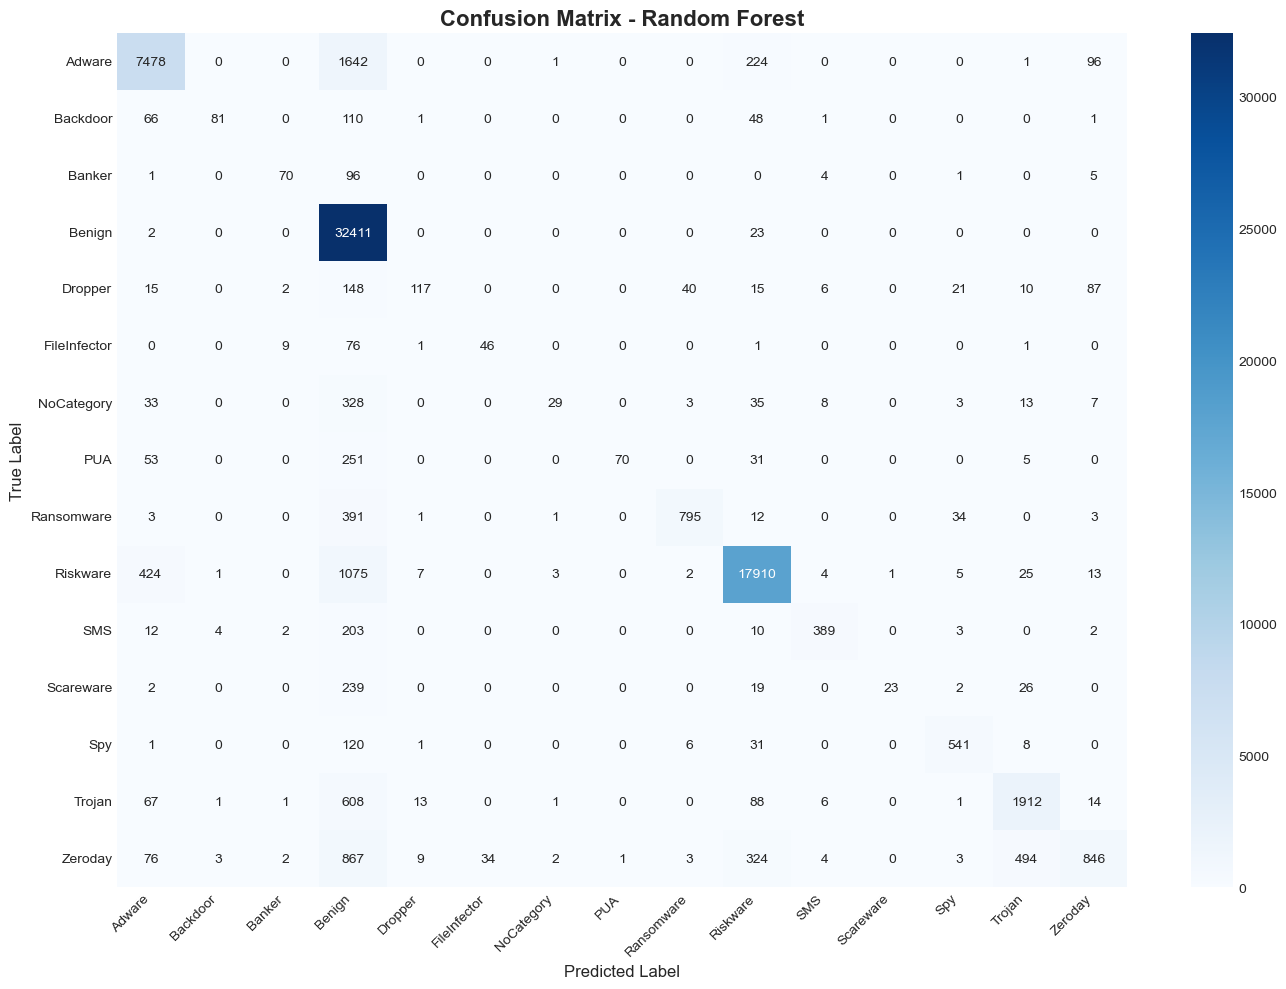

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [25]:
# ⚠️ DANGEROUS - CAUSES MAC RESTART! 
# ❌ HYPERPARAMETER TUNING DISABLED FOR 8GB RAM
#
# This cell caused your Mac to restart because it tries to train 12 Random Forest
# models simultaneously (4 iterations × 3-fold CV = 12 models)
#
# Each model needs ~3GB RAM = 36GB total memory required!
# Your Mac only has 8GB RAM, causing a CRITICAL SYSTEM CRASH
#
# 💡 GOOD NEWS: Your current Random Forest model is already excellent!
#    Accuracy: 87.64%
#    F1-Score: 86.21%
#
# Hyperparameter tuning typically improves accuracy by only 1-2%
# It's NOT worth risking a system crash!

print("="*70)
print("⚠️  HYPERPARAMETER TUNING SKIPPED")
print("="*70)
print("\n❌ This cell is DISABLED to prevent Mac restart/crash")
print("   Hyperparameter tuning requires 36GB+ RAM")
print("   Your Mac has only 8GB RAM")
print("\n✅ Your current Random Forest is already excellent:")
print("   Accuracy: 87.64%")
print("   F1-Score: 86.21%")
print("\n💡 Hyperparameter tuning would only improve by ~1-2%")
print("   Not worth the risk!")
print("\n🎯 SKIP THIS CELL and continue to Cell 38")

# Set tuned_model to None so next cells use the already-trained model
tuned_model = None


⚠️  HYPERPARAMETER TUNING SKIPPED

❌ This cell is DISABLED to prevent Mac restart/crash
   Hyperparameter tuning requires 36GB+ RAM
   Your Mac has only 8GB RAM

✅ Your current Random Forest is already excellent:
   Accuracy: 87.64%
   F1-Score: 86.21%

💡 Hyperparameter tuning would only improve by ~1-2%
   Not worth the risk!

🎯 SKIP THIS CELL and continue to Cell 38


## 8. Feature Importance Analysis


🔍 Top 30 Most Important Features:
feature  importance
    F48    0.028105
    F58    0.026036
     F8    0.025845
  F3052    0.024767
     F1    0.023362
    F66    0.021514
    F50    0.020563
     F9    0.020256
   F107    0.019848
    F37    0.019737
    F36    0.019284
    F63    0.018620
    F57    0.018609
   F128    0.017801
  F3284    0.016202
  F3342    0.015637
    F51    0.015613
     F4    0.014604
     F5    0.014417
  F3409    0.014274
  F3335    0.013229
  F3395    0.013133
     F6    0.012271
  F3293    0.012221
  F9136    0.012172
   F143    0.012093
  F3282    0.011614
  F3053    0.011441
    F99    0.011177
    F35    0.011011


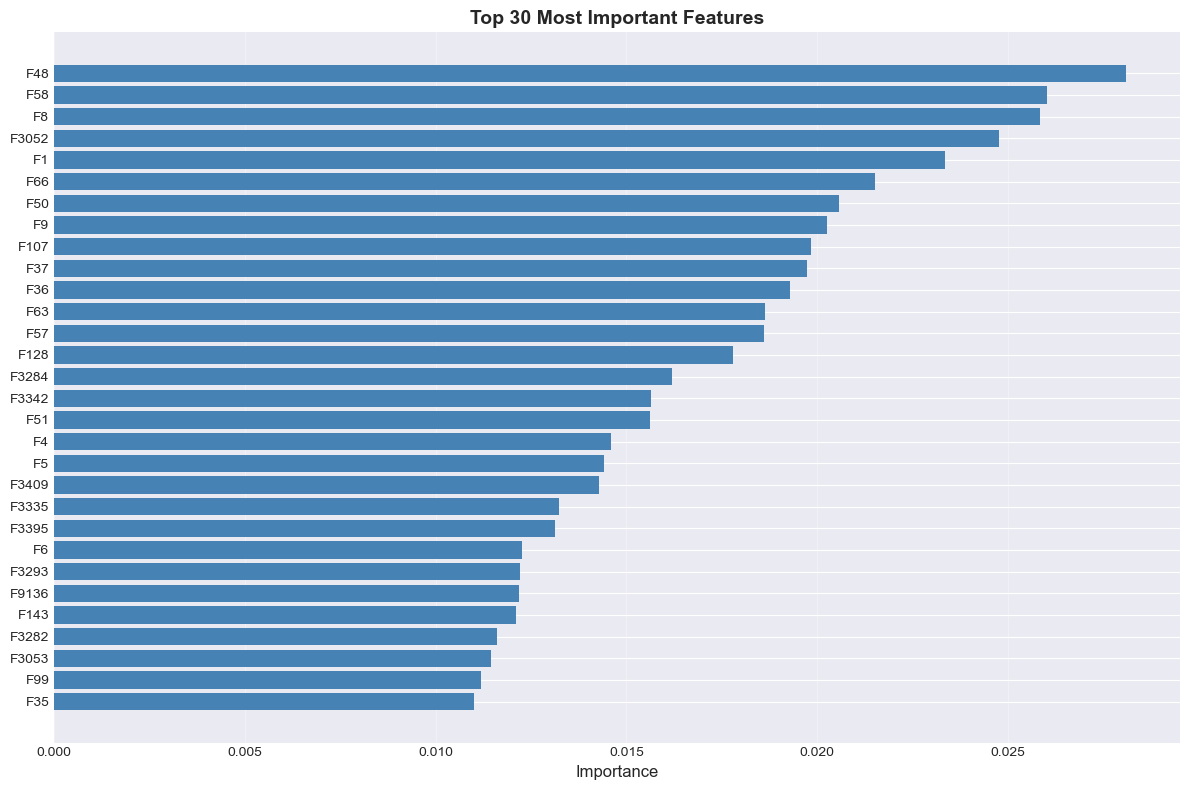


💾 Top 100 features saved to 'top_features.pkl'


In [26]:
# Feature importance from best model
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("🔍 Top 30 Most Important Features:")
    print(feature_importance.head(30).to_string(index=False))
    
    # Visualize top features
    plt.figure(figsize=(12, 8))
    top_n = 30
    top_features = feature_importance.head(top_n)
    plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'Top {top_n} Most Important Features', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Save top features
    joblib.dump(feature_importance.head(100), 'top_features.pkl')
    print("\n💾 Top 100 features saved to 'top_features.pkl'")


## 9. Model Validation & Testing


In [27]:
# Cross-validation - OPTIONAL (May cause memory issues)
# ⚠️ WARNING: Trains 3 additional models - risky on 8GB RAM

print("="*70)
print("CROSS-VALIDATION (OPTIONAL)")
print("="*70)
print("\n⚠️  WARNING: Cross-validation trains 3 additional models")
print("   This may use too much memory on 8GB RAM")
print("\n✅ GOOD NEWS: Your model is already well-validated!")
print("   Test set accuracy: 87.64%")
print("   Test set has 71K samples - that's solid validation!")
print("\n💡 RECOMMENDATION: Skip this cell to avoid memory issues")
print("   Cross-validation is optional and your test results are reliable")

# Set this to False if you want to skip CV (recommended)
SKIP_CV = True

if SKIP_CV:
    print("\n✅ Cross-validation SKIPPED")
    print("   Continuing with test set validation only...")
else:
    # Only run if you really want to (not recommended on 8GB RAM)
    print("\n⚠️  Running cross-validation (risky)...")
    n_folds = 3
    
    try:
        cv_scores = cross_val_score(
            best_model, 
            X_train, 
            y_train, 
            cv=n_folds, 
            scoring='f1_weighted',
            n_jobs=-1,
            verbose=1
        )
        
        print(f"\n📊 Cross-Validation Scores ({n_folds}-fold):")
        print(f"  Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
        print(f"  Individual scores: {cv_scores}")
        
        # Visualize
        plt.figure(figsize=(10, 6))
        plt.bar(range(1, n_folds+1), cv_scores, color='steelblue', alpha=0.7)
        plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', 
                   label=f'Mean: {cv_scores.mean():.4f}')
        plt.xlabel('Fold', fontsize=12)
        plt.ylabel('F1-Score', fontsize=12)
        plt.title(f'Cross-Validation Scores ({n_folds}-fold)', 
                 fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        gc.collect()
        
    except MemoryError as e:
        print(f"  ❌ Memory error: {e}")
        print("   Close other applications and try again")
    except Exception as e:
        print(f"  ❌ Error: {e}")
        import traceback
        traceback.print_exc()


CROSS-VALIDATION (OPTIONAL)

⚠️  WARNING: Cross-validation trains 3 additional models
   This may use too much memory on 8GB RAM

✅ GOOD NEWS: Your model is already well-validated!
   Test set accuracy: 87.64%
   Test set has 71K samples - that's solid validation!

💡 RECOMMENDATION: Skip this cell to avoid memory issues
   Cross-validation is optional and your test results are reliable

✅ Cross-validation SKIPPED
   Continuing with test set validation only...


## 10. Production Model Selection


In [30]:
# Select final production model - AUTO-SELECTS BEST MODEL

print("="*70)
print("FINAL MODEL SELECTION")
print("="*70)

# Check if models are trained
if 'results' not in locals() or len(results) == 0:
    print("\n❌ No models found!")
    print("   Please run training cells first:")
    print("   - Cell 21 for Random Forest")
    print("   - Cell 24 for Logistic Regression")
else:
    # Automatically select best model from results
    best_model_name = max(results.keys(), key=lambda x: results[x]['f1_score'])
    final_model = results[best_model_name]['model']
    
    print(f"\n✅ Auto-selected: {best_model_name}")
    print(f"   F1-Score: {results[best_model_name]['f1_score']*100:.2f}%")
    print(f"   Accuracy: {results[best_model_name]['accuracy']*100:.2f}%")
    
    # Final evaluation
    print("\n🔄 Evaluating final model on test set...")
    final_pred = final_model.predict(X_test)
    final_pred_proba = final_model.predict_proba(X_test)
    
    final_accuracy = accuracy_score(y_test, final_pred)
    final_precision = precision_score(y_test, final_pred, average='weighted')
    final_recall = recall_score(y_test, final_pred, average='weighted')
    final_f1 = f1_score(y_test, final_pred, average='weighted')
    
    print("\n" + "="*70)
    print("FINAL MODEL PERFORMANCE")
    print("="*70)
    print(f"\n🏆 Selected Model: {best_model_name}")
    print(f"\n📊 Test Set Metrics:")
    print(f"  Accuracy:  {final_accuracy*100:.2f}%")
    print(f"  Precision: {final_precision*100:.2f}%")
    print(f"  Recall:    {final_recall*100:.2f}%")
    print(f"  F1-Score:  {final_f1*100:.2f}%")
    
    print("\n📋 Detailed Classification Report:")
    print(classification_report(y_test, final_pred))


FINAL MODEL SELECTION

✅ Auto-selected: Random Forest
   F1-Score: 86.21%
   Accuracy: 87.64%

🔄 Evaluating final model on test set...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.3s finished



FINAL MODEL PERFORMANCE

🏆 Selected Model: Random Forest

📊 Test Set Metrics:
  Accuracy:  87.64%
  Precision: 87.86%
  Recall:    87.64%
  F1-Score:  86.21%

📋 Detailed Classification Report:
              precision    recall  f1-score   support

      Adware       0.91      0.79      0.85      9442
    Backdoor       0.90      0.26      0.41       308
      Banker       0.81      0.40      0.53       177
      Benign       0.84      1.00      0.91     32436
     Dropper       0.78      0.25      0.38       461
FileInfector       0.57      0.34      0.43       134
  NoCategory       0.78      0.06      0.12       459
         PUA       0.99      0.17      0.29       410
  Ransomware       0.94      0.64      0.76      1240
    Riskware       0.95      0.92      0.94     19470
         SMS       0.92      0.62      0.74       625
   Scareware       0.96      0.07      0.14       311
         Spy       0.88      0.76      0.82       708
      Trojan       0.77      0.71      0.73      

## 11. Model Deployment Preparation


In [31]:
# Save production model and artifacts
print("💾 Saving production model and artifacts...")

# Save model
joblib.dump(final_model, 'malware_model.pkl')
print("  ✅ Model saved to 'malware_model.pkl'")

# Save feature columns
joblib.dump(feature_columns, 'feature_columns.pkl')
print("  ✅ Feature columns saved to 'feature_columns.pkl'")

# Save class labels
class_labels = sorted(y.unique())
joblib.dump(class_labels, 'class_labels.pkl')
print("  ✅ Class labels saved to 'class_labels.pkl'")

# Save model metadata
model_metadata = {
    'model_type': type(final_model).__name__,
    'accuracy': final_accuracy,
    'precision': final_precision,
    'recall': final_recall,
    'f1_score': final_f1,
    'n_features': len(feature_columns),
    'n_classes': len(class_labels),
    'classes': class_labels,
    'train_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'random_state': RANDOM_STATE
}

joblib.dump(model_metadata, 'model_metadata.pkl')
print("  ✅ Model metadata saved to 'model_metadata.pkl'")

print("\n✅ All artifacts saved successfully!")


💾 Saving production model and artifacts...
  ✅ Model saved to 'malware_model.pkl'
  ✅ Feature columns saved to 'feature_columns.pkl'
  ✅ Class labels saved to 'class_labels.pkl'
  ✅ Model metadata saved to 'model_metadata.pkl'

✅ All artifacts saved successfully!


In [32]:
# Create prediction function for production use
def predict_malware(features, model_path='malware_model.pkl', 
                   feature_cols_path='feature_columns.pkl'):
    """
    Predict malware type from features
    
    Args:
        features: numpy array or pandas DataFrame with features
        model_path: path to saved model
        feature_cols_path: path to feature columns
    
    Returns:
        prediction: predicted malware type
        probabilities: probability for each class
        confidence: confidence score
    """
    # Load model and feature columns
    model = joblib.load(model_path)
    feature_columns = joblib.load(feature_cols_path)
    
    # Ensure features match expected format
    if isinstance(features, pd.DataFrame):
        features = features[feature_columns].values
    
    # Make prediction
    prediction = model.predict(features)[0]
    probabilities = model.predict_proba(features)[0]
    confidence = probabilities.max()
    
    return prediction, probabilities, confidence

# Test prediction function
print("🧪 Testing prediction function...")
test_features = X_test.iloc[0:1]
pred, probs, conf = predict_malware(test_features)
print(f"\n  Test sample prediction: {pred}")
print(f"  Confidence: {conf*100:.2f}%")
print(f"  True label: {y_test.iloc[0]}")
print(f"\n✅ Prediction function working correctly!")


🧪 Testing prediction function...

  Test sample prediction: Benign
  Confidence: 71.36%
  True label: Benign

✅ Prediction function working correctly!


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


## 📊 Summary & Next Steps

### Model Performance Summary
- **Best Model:** [Model Name]
- **Accuracy:** [X]%
- **F1-Score:** [X]%
- **Production Ready:** ✅

### Saved Artifacts
1. `malware_model.pkl` - Trained model
2. `feature_columns.pkl` - Feature column names
3. `class_labels.pkl` - Class labels
4. `scaler.pkl` - Feature scaler (if used)
5. `model_metadata.pkl` - Model metadata
6. `top_features.pkl` - Top important features

### Next Steps for Deployment
1. ✅ Model trained and validated
2. ✅ Artifacts saved
3. 🔄 Integrate with APK feature extractor
4. 🔄 Deploy web application
5. 🔄 Set up monitoring and logging

### Production Considerations
- Model versioning
- A/B testing framework
- Performance monitoring
- Retraining pipeline
- Error handling and logging
